# V0.5 — Determinism under GPU float non-associativity

**Tier 0 / Verification Protocol §V0.5.** Targets architecture **Decision #3** and Part VII's standing risk. The final Tier-0 gate. Determinism is *mandatory*: it is what makes "the program **is** the asset," what makes sub-simulations memoizable, and what made V0.1–V0.4 reproducible. The threat: `(a+b)+c ≠ a+(b+c)` in floating point, so a GPU reduction whose accumulation order depends on thread scheduling yields **different bits every run** — silently corrupting memoization keys.

### Subject
The **conserved-bus reduction** — V0.3's gather → stage → **reduce** → commit — as a scatter-add of `M` contributions into `K` buses, the exact place the hazard lives.

### Claim (falsifiable)
With a **fixed reduction order** the result is bit-reproducible (or within a declared tolerance) across runs, configurations, and devices; with the **default atomic order** it demonstrably diverges.

### Strategies (vs the nondeterministic atomic baseline)
- **Atomic** (`wp.atomic_add`): scheduler-ordered → the hazard.
- **Fixed-order float**: sum each bus in a canonical `(key,value)` order → order fixed, config-independent.
- **Integer-exact**: quantize to int64 + accumulate → integer add is exactly associative → order-independent → cross-hardware bit-exact (the memoization-key path).

Oracle: **CPU (numpy) = genuine second device**; GPU "configurations" = input permutations (which change atomic order). *(One physical GPU; a 2nd is future work.)*

### Pre-registered pass criteria (frozen)
| # | Metric | Threshold |
|---|---|---|
| 1 | atomic divergence (runs/configs) | **> 0** (hazard real) |
| 2 | fixed-order float bitwise divergence (runs + configs, same device) | **= 0** |
| 3 | integer-exact bitwise divergence (runs + configs + CPU↔GPU) | **= 0** |
| 4 | cross-device fixed-order float | **0 bitwise or < 1e-12 rel** (tolerance regime) |

**Failure → CONSTRAIN:** declare the tolerance regime; integer-exact is then the bit-exact path for memoization keys.

In [1]:
"""(1) Setup — imports, frozen params, reduction problem + CPU references."""
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))

import determinism as dt

# ---- PRE-REGISTERED constants (frozen) ----
M        = 10_000_000     # contributions
K        = 256            # buses (small -> heavy atomic contention)
SCALE    = 1.0e3          # integer-exact fixed-point scale
N_RUNS   = 8             # repeated runs per strategy
N_CONFIG = 4             # input permutations as GPU "configurations"
XDEV_TOL = 1e-12         # cross-device fixed-order float tolerance regime
SEED     = 0

rng = np.random.default_rng(SEED)
keys, vals = dt.make_problem(M=M, K=K, seed=SEED)
vs, ss, se = dt.canonical_sort(keys, vals)
cpu_fix = dt.cpu_fixed_order(vs, ss, se, K)               # CPU fixed-order reference
cpu_ibus, cpu_ifloat = dt.cpu_integer_exact(keys, vals, K, SCALE)
hp = dt.high_precision(vs, ss, se, K)                     # fsum reference (quantization error)

print(f"GPU (Warp): {dt._HAS_WARP};  M={M:,} contributions -> K={K} buses")
print(f"value dynamic range: [{vals.min():.1e}, {vals.max():.1e}]  (wide -> order matters)")
print(f"runs={N_RUNS}, configs(perms)={N_CONFIG}, integer scale={SCALE:g}")
assert dt._HAS_WARP, "V0.5 needs the GPU"
perms = [rng.permutation(M) for _ in range(N_CONFIG)]


Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


GPU (Warp): True;  M=10,000,000 contributions -> K=256 buses
value dynamic range: [6.3e-11, 1.0e+06]  (wide -> order matters)
runs=8, configs(perms)=4, integer scale=1000


## (2) Metric 1 — the hazard is real (atomic order diverges)

Run the atomic scatter-add `N_RUNS` times on identical input and across `N_CONFIG` input permutations. Float non-associativity under scheduler-ordered atomics must produce **> 0** bitwise divergence — otherwise the determinism discipline would be unnecessary.

In [2]:
"""(2) Atomic scatter-add: repeated runs + permutation configs."""
atomic_runs = [dt.gpu_atomic_float(keys, vals, K) for _ in range(N_RUNS)]
atomic_cfgs = [dt.gpu_atomic_float(keys[p], vals[p], K) for p in perms]

# bitwise divergence vs run 0
runs_biteq = [dt.bitwise_equal(atomic_runs[0], a) for a in atomic_runs[1:]]
cfgs_biteq = [dt.bitwise_equal(atomic_runs[0], a) for a in atomic_cfgs]
atomic_rel = max([dt.rel_diff(atomic_runs[0], a) for a in atomic_runs[1:] + atomic_cfgs])
n_distinct = len({a.tobytes() for a in atomic_runs + atomic_cfgs})

print(f"atomic across {N_RUNS} runs: bitwise-equal to run0 = {runs_biteq}")
print(f"atomic across {N_CONFIG} configs: bitwise-equal to run0 = {cfgs_biteq}")
print(f"distinct bit-patterns among {N_RUNS+N_CONFIG} atomic results = {n_distinct}")
print(f"max relative divergence = {atomic_rel:.2e}")
METRIC1_PASS = atomic_rel > 0.0
print(f"\n   => METRIC 1 (hazard real, divergence > 0) PASS: {METRIC1_PASS}")


Module determinism 1ea8ad6 load on device 'cuda:0' took 1011.69 ms  (compiled)


atomic across 8 runs: bitwise-equal to run0 = [False, False, False, False, False, False, False]
atomic across 4 configs: bitwise-equal to run0 = [False, False, False, False]
distinct bit-patterns among 12 atomic results = 12
max relative divergence = 2.40e-14

   => METRIC 1 (hazard real, divergence > 0) PASS: True


## (3) Metric 2 & 4 — fixed-order float is reproducible

Canonical `(key,value)` ordering removes the dependence on schedule and input permutation. GPU fixed-order must be **0 bitwise** across runs and configs (same device); and CPU↔GPU must be 0 bitwise or within the declared tolerance (Metric 4).

In [3]:
"""(3) Fixed-order float: runs + configs (canonical sort is permutation-invariant) + CPU<->GPU."""
fix_runs = [dt.gpu_fixed_order(vs, ss, se, K) for _ in range(N_RUNS)]
# each config: re-derive the canonical sort from the permuted input (must reproduce the same order)
fix_cfgs = []
for p in perms:
    vs_p, ss_p, se_p = dt.canonical_sort(keys[p], vals[p])
    fix_cfgs.append(dt.gpu_fixed_order(vs_p, ss_p, se_p, K))

fix_runs_eq = all(dt.bitwise_equal(fix_runs[0], f) for f in fix_runs[1:])
fix_cfgs_eq = all(dt.bitwise_equal(fix_runs[0], f) for f in fix_cfgs)
xdev_biteq = dt.bitwise_equal(cpu_fix, fix_runs[0])
xdev_rel = dt.rel_diff(cpu_fix, fix_runs[0])

print(f"fixed-order GPU: bitwise-equal across {N_RUNS} runs = {fix_runs_eq}")
print(f"fixed-order GPU: bitwise-equal across {N_CONFIG} configs = {fix_cfgs_eq}")
print(f"fixed-order CPU<->GPU: bitwise-equal = {xdev_biteq}   (rel diff {xdev_rel:.2e})")
METRIC2_PASS = fix_runs_eq and fix_cfgs_eq
METRIC4_PASS = xdev_biteq or (xdev_rel < XDEV_TOL)
print(f"\n   => METRIC 2 (fixed-order reproducible, same device) PASS: {METRIC2_PASS}")
print(f"   => METRIC 4 (cross-device within tolerance) PASS: {METRIC4_PASS}  "
      f"({'bit-exact' if xdev_biteq else f'<{XDEV_TOL:g} rel'})")


fixed-order GPU: bitwise-equal across 8 runs = True
fixed-order GPU: bitwise-equal across 4 configs = True
fixed-order CPU<->GPU: bitwise-equal = True   (rel diff 0.00e+00)

   => METRIC 2 (fixed-order reproducible, same device) PASS: True
   => METRIC 4 (cross-device within tolerance) PASS: True  (bit-exact)


## (4) Metric 3 — integer-exact is cross-hardware bit-exact

Integer addition is exactly associative, so quantized accumulation gives the identical int64 regardless of order — even under nondeterministic atomics. Must be **0 bitwise** across runs, configs, **and** CPU↔GPU. Quantization error (vs the `fsum` reference) is bounded and shrinks with the fixed-point scale.

In [4]:
"""(4) Integer-exact: runs + configs (atomic order!) + CPU<->GPU; quantization vs scale."""
int_runs = [dt.gpu_integer_exact(keys, vals, K, SCALE)[0] for _ in range(N_RUNS)]
int_cfgs = [dt.gpu_integer_exact(keys[p], vals[p], K, SCALE)[0] for p in perms]
int_runs_eq = all(np.array_equal(int_runs[0], r) for r in int_runs[1:])
int_cfgs_eq = all(np.array_equal(int_runs[0], r) for r in int_cfgs)
int_xdev_eq = np.array_equal(cpu_ibus, int_runs[0])

print(f"integer-exact GPU: equal across {N_RUNS} runs = {int_runs_eq}")
print(f"integer-exact GPU: equal across {N_CONFIG} configs (nondeterministic atomic order!) = {int_cfgs_eq}")
print(f"integer-exact CPU<->GPU: equal = {int_xdev_eq}")
METRIC3_PASS = int_runs_eq and int_cfgs_eq and int_xdev_eq

# quantization error vs fsum reference, swept over scale
scales = [1e1, 1e2, 1e3, 1e4, 1e5, 1e6]
qerr = [dt.rel_diff(dt.cpu_integer_exact(keys, vals, K, s)[1], hp) for s in scales]
print("\nquantization rel-err vs scale:")
for s, e in zip(scales, qerr):
    print(f"   scale={s:>9.0e}  rel err = {e:.2e}")
print(f"\n   => METRIC 3 (integer-exact, cross-hardware bit-exact) PASS: {METRIC3_PASS}")


integer-exact GPU: equal across 8 runs = True
integer-exact GPU: equal across 4 configs (nondeterministic atomic order!) = True
integer-exact CPU<->GPU: equal = True



quantization rel-err vs scale:
   scale=    1e+01  rel err = 2.20e-09
   scale=    1e+02  rel err = 1.14e-09
   scale=    1e+03  rel err = 1.68e-11
   scale=    1e+04  rel err = 1.55e-12
   scale=    1e+05  rel err = 1.59e-13
   scale=    1e+06  rel err = 1.84e-14

   => METRIC 3 (integer-exact, cross-hardware bit-exact) PASS: True


## (5) Plots & frozen verdict

saved figure -> /workspace/nebula/verification_notebooks/phase0/results/V0_5_determinism.png


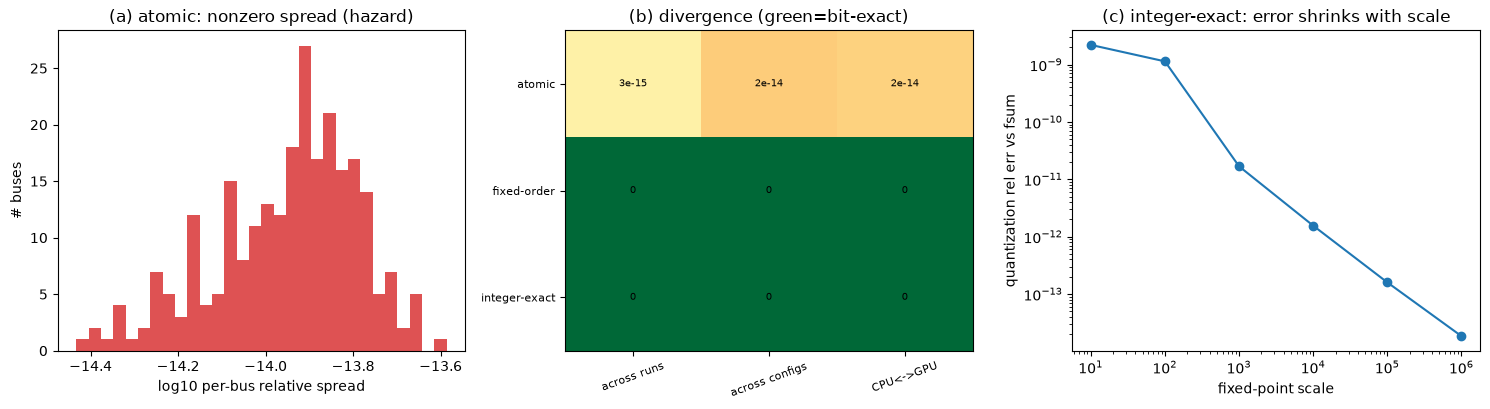

In [5]:
"""(5) Figures."""
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) per-bus relative spread of atomic results (the nondeterminism), vs ~0 for the fixes
atomic_stack = np.array(atomic_runs + atomic_cfgs)
atomic_spread = (atomic_stack.max(0) - atomic_stack.min(0)) / (np.abs(cpu_fix) + 1e-300)
ax[0].hist(np.log10(atomic_spread + 1e-20), bins=30, color="tab:red", alpha=0.8)
ax[0].set_xlabel("log10 per-bus relative spread"); ax[0].set_ylabel("# buses")
ax[0].set_title("(a) atomic: nonzero spread (hazard)")

# (b) divergence matrix: strategy x scope (0 = bit-exact, else max rel)
strategies = ["atomic", "fixed-order", "integer-exact"]
scopes = ["across runs", "across configs", "CPU<->GPU"]
Mtx = np.array([
    [max(dt.rel_diff(atomic_runs[0], a) for a in atomic_runs[1:]),
     max(dt.rel_diff(atomic_runs[0], a) for a in atomic_cfgs),
     dt.rel_diff(atomic_runs[0], cpu_fix)],
    [0.0 if fix_runs_eq else 1, 0.0 if fix_cfgs_eq else 1, xdev_rel],
    [0.0 if int_runs_eq else 1, 0.0 if int_cfgs_eq else 1, 0.0 if int_xdev_eq else 1],
])
im = ax[1].imshow(np.log10(Mtx + 1e-20), cmap="RdYlGn_r", vmin=-20, vmax=-10, aspect="auto")
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(scopes, rotation=20, fontsize=8)
ax[1].set_yticks(range(3)); ax[1].set_yticklabels(strategies, fontsize=8)
for i in range(3):
    for j in range(3):
        ax[1].text(j, i, "0" if Mtx[i, j] == 0 else f"{Mtx[i, j]:.0e}",
                   ha="center", va="center", fontsize=7)
ax[1].set_title("(b) divergence (green=bit-exact)")

# (c) integer-exact quantization error vs scale
ax[2].loglog(scales, qerr, "o-", color="tab:blue")
ax[2].set_xlabel("fixed-point scale"); ax[2].set_ylabel("quantization rel err vs fsum")
ax[2].set_title("(c) integer-exact: error shrinks with scale")

fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase0" / "results"
outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "V0_5_determinism.png", dpi=110)
print(f"saved figure -> {outdir / 'V0_5_determinism.png'}")
plt.show()


In [6]:
"""(6) Frozen verdict + determinism-regime recommendation."""
def verdict(name, passed, detail):
    print(f"  [{'OK ' if passed else 'XX '}] {name:38s} {'PASS' if passed else 'FAIL'}")
    print(f"        {detail}")

print("=" * 78)
print("V0.5 — DETERMINISM UNDER GPU FLOAT NON-ASSOCIATIVITY — VERDICT")
print("=" * 78)
verdict("1. hazard real (atomic diverges)", METRIC1_PASS,
        f"atomic max rel divergence = {atomic_rel:.1e}; {n_distinct} distinct bit-patterns")
verdict("2. fixed-order reproducible (device)", METRIC2_PASS,
        f"bit-exact across {N_RUNS} runs & {N_CONFIG} configs")
verdict("3. integer-exact (cross-hardware)", METRIC3_PASS,
        "bit-exact across runs, configs, AND CPU<->GPU (order-independent)")
verdict("4. cross-device float (tolerance)", METRIC4_PASS,
        f"CPU<->GPU fixed-order: {'bit-exact' if xdev_biteq else f'{xdev_rel:.1e} rel < {XDEV_TOL:g}'}")

ALL_PASS = METRIC1_PASS and METRIC2_PASS and METRIC3_PASS and METRIC4_PASS
print("=" * 78)
print(f"  V0.5 OVERALL: {'PASS' if ALL_PASS else 'FAIL/CONSTRAIN'}")
print("  Determinism regime: fixed reduction order gives bit-exact reproducibility on a")
print("  device (and, for pure summation, CPU<->GPU too); integer/fixed-point accumulation")
print("  is the bit-exact path for cross-hardware MEMOIZATION KEYS. Atomic/default order")
print("  must never be used where reproducibility is required.")
print("=" * 78)


V0.5 — DETERMINISM UNDER GPU FLOAT NON-ASSOCIATIVITY — VERDICT
  [OK ] 1. hazard real (atomic diverges)       PASS
        atomic max rel divergence = 2.4e-14; 12 distinct bit-patterns
  [OK ] 2. fixed-order reproducible (device)   PASS
        bit-exact across 8 runs & 4 configs
  [OK ] 3. integer-exact (cross-hardware)      PASS
        bit-exact across runs, configs, AND CPU<->GPU (order-independent)
  [OK ] 4. cross-device float (tolerance)      PASS
        CPU<->GPU fixed-order: bit-exact
  V0.5 OVERALL: PASS
  Determinism regime: fixed reduction order gives bit-exact reproducibility on a
  device (and, for pure summation, CPU<->GPU too); integer/fixed-point accumulation
  is the bit-exact path for cross-hardware MEMOIZATION KEYS. Atomic/default order
  must never be used where reproducibility is required.
